# 06 — Full-Corpus Prediction Analysis

Runs the best fine-tuned model over all **~1M Russian tweets** and produces:

- `outputs/6_full_corpus/predictions_full.csv` — `Date`, `Id`, `Tweet Treated`, `y_prob`, `y_pred` (local use only)
- `outputs/6_full_corpus/predictions_ids.csv` — `Id`, `y_pred` (publishable under Twitter's data-sharing policy)

Then analyses the predictions to answer:
1. What is the predicted prevalence of hate speech in the full corpus?
2. How does hate speech probability evolve over time — does it spike around the Feb 24 2022 invasion?
3. How does predicted prevalence compare with the 20.7% rate in the annotated subset?

> **Prerequisite** — the model `tomh/toxigen_roberta` fine-tuned with K=5 ratio raw must exist under `outputs/3_training/` (run notebook 03 first).

> **Checkpointing** — inference is saved every `CHECKPOINT_EVERY` rows. If the kernel crashes, re-run the inference cell and it will resume from where it stopped.

In [1]:
import sys, os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from src.evaluation import discover_models
from src.data_preprocessing.russian_processor import RussianProcessor

sns.set_theme(style='whitegrid')

c:\Users\Alexandre\miniconda3\envs\faiss2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Configuration

In [2]:
CONFIG_PATH = 'configs/datasets.yaml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# ── Model selection ───────────────────────────────────────────────────────────
MODEL_SLUG  = 'tomh_toxigen_roberta'   # model_slug as stored under outputs/3_training/
DENSITY_TAG = 'density_k5_ratio'       # density_tag of the run to use
TRAIN_DS    = 'toxigen'                # dataset the model was trained on
# ─────────────────────────────────────────────────────────────────────────────

# ── Inference settings ────────────────────────────────────────────────────────
BATCH_SIZE        = 64
MAX_LENGTH        = cfg['training']['max_length']
THRESHOLD         = 0.5
CHECKPOINT_EVERY  = 50_000   # save progress every N samples
# ─────────────────────────────────────────────────────────────────────────────

# ── Paths ─────────────────────────────────────────────────────────────────────
TRAINING_ROOT      = cfg['training']['output_root']
FULL_CORPUS_PATH   = cfg['datasets']['russian']['full_corpus_path']
OUTPUT_DIR         = 'outputs/6_full_corpus'
CHECKPOINT_PATH    = os.path.join(OUTPUT_DIR, 'checkpoint.csv')
PREDICTIONS_FULL   = os.path.join(OUTPUT_DIR, 'predictions_full.csv')
PREDICTIONS_IDS    = os.path.join(OUTPUT_DIR, 'predictions_ids.csv')
ANNOTATED_PREV     = 0.207   # known prevalence in annotated subset (20.7%)
INVASION_DATE      = pd.Timestamp('2022-02-24')
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Output dir     :', OUTPUT_DIR)
print('Full corpus    :', FULL_CORPUS_PATH)
print('Checkpoint     :', CHECKPOINT_PATH)

Output dir     : outputs/6_full_corpus
Full corpus    : data/raw/russian/completeDataset_inference.csv
Checkpoint     : outputs/6_full_corpus\checkpoint.csv


## 1. Locate Model

In [3]:
all_models = discover_models(TRAINING_ROOT, specialists=False)

candidates = [
    m for m in all_models
    if MODEL_SLUG in m['model_slug']
    and m['density_tag'] == DENSITY_TAG
    and m['dataset'] == TRAIN_DS
]

if not candidates:
    raise RuntimeError(
        f'No model found matching slug={MODEL_SLUG!r}, density_tag={DENSITY_TAG!r}, dataset={TRAIN_DS!r}.\n'
        f'Available models:\n' + '\n'.join(f'  {m["run_name"]}' for m in all_models)
    )

# If multiple candidates exist (e.g. repeated runs), take the first
MODEL_META = candidates[0]
MODEL_PATH = MODEL_META['model_path']

print(f'Using model    : {MODEL_META["run_name"]}')
print(f'Model path     : {MODEL_PATH}')
if len(candidates) > 1:
    print(f'[INFO] {len(candidates)} candidates found — using first. Set MODEL_PATH manually to override.')

Using model    : tomh_toxigen_roberta__toxigen__density_k5_ratio
Model path     : outputs/3_training\tomh_toxigen_roberta\toxigen__density_k5_ratio\model


## 2. Load Full Corpus

In [4]:
proc = RussianProcessor(
    annotated_path   = cfg['datasets']['russian']['annotated_path'],
    full_corpus_path = FULL_CORPUS_PATH,
)

corpus_df = proc.load_full_corpus_df()

# Normalise column names for consistent access
col_map  = {c.lower().strip(): c for c in corpus_df.columns}
ID_COL   = col_map.get('id')
DATE_COL = col_map.get('date')

if DATE_COL:
    corpus_df['date_parsed'] = pd.to_datetime(corpus_df[DATE_COL], errors='coerce', utc=True)
    n_bad = corpus_df['date_parsed'].isna().sum()
    print(f'Parsed dates   : {len(corpus_df) - n_bad:,} ok  |  {n_bad:,} unparseable')
else:
    print('[WARN] No date column found — temporal analysis will be skipped.')

print(f'\nCorpus shape   : {corpus_df.shape}')
print(f'Columns        : {list(corpus_df.columns)}')
corpus_df.head(3)

  [Russian] Loaded 1021221 rows from full corpus
Parsed dates   : 1,021,221 ok  |  0 unparseable

Corpus shape   : (1021221, 11)
Columns        : ['Date', 'Tweet Treated', 'Tweet Raw', 'Url', 'Id', 'index', 'model_inference', 'normal_score', 'hate_speech_score', 'text', 'date_parsed']


,Date,Tweet Treated,Tweet Raw,Url,Id,index,model_inference,normal_score,hate_speech_score,text,date_parsed
0,2022-01-01 23:59:41+00:00,goldfinger &amp; from russia with love,@donwinslow Goldfinger &amp; From Russia with ...,https://twitter.com/coolvee2222/status/1477429...,1477429351952130051,0,nothate,0.9996,0.0004,goldfinger &amp; from russia with love,2022-01-01 23:59:41+00:00
1,2022-01-01 23:59:23+00:00,thank you! russia musume 1 or dream note please!,@aiuncensored thank you! russia musume 1 or dr...,https://twitter.com/CsarVsq30904305/status/147...,1477429275926179841,1,nothate,0.9997,0.0003,thank you! russia musume 1 or dream note please!,2022-01-01 23:59:23+00:00
2,2022-01-01 23:59:23+00:00,"new in shop! vintage russian nesting dolls, cl...","New in Shop! Vintage Russian Nesting Dolls, Cl...",https://twitter.com/trashtique/status/14774292...,1477429275024310273,2,nothate,0.9997,0.0003,"new in shop! vintage russian nesting dolls, cl...",2022-01-01 23:59:23+00:00


## 3. Run Inference

Processes the full corpus in batches and saves a checkpoint every
`CHECKPOINT_EVERY` rows. Re-running this cell resumes from the last checkpoint.

In [5]:
texts = corpus_df['text'].tolist()
n_total = len(texts)

# ── Resume from checkpoint if it exists ──────────────────────────────────────
start_idx = 0
all_probs: list[float] = []

if os.path.exists(CHECKPOINT_PATH):
    ckpt = pd.read_csv(CHECKPOINT_PATH)
    all_probs = ckpt['y_prob'].tolist()
    start_idx = len(all_probs)
    print(f'Resuming from checkpoint: {start_idx:,} / {n_total:,} samples already done.')
    if start_idx >= n_total:
        print('All samples already processed — skipping inference.')
else:
    print(f'Starting fresh inference on {n_total:,} samples.')

# ── Inference loop ────────────────────────────────────────────────────────────
if start_idx < n_total:
    # Monkey-patch to bypass torch.load safety check (transformers <4.40 compat)
    import transformers.utils.import_utils
    import transformers.modeling_utils
    for mod in [transformers.utils.import_utils, transformers.modeling_utils]:
        if hasattr(mod, 'check_torch_load_is_safe'):
            mod.check_torch_load_is_safe = lambda: None

    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
    model.eval()

    id2label = model.config.id2label
    hate_idx = next(
        (i for i, l in id2label.items() if 'hate' in str(l).lower() and 'no' not in str(l).lower()),
        1,
    )
    print(f'Device: {device}  |  hate class index: {hate_idx}')

    remaining = texts[start_idx:]
    with torch.no_grad():
        for i in tqdm(range(0, len(remaining), BATCH_SIZE), desc='Inference'):
            batch = remaining[i : i + BATCH_SIZE]
            enc   = tokenizer(
                batch, padding=True, truncation=True,
                max_length=MAX_LENGTH, return_tensors='pt',
            ).to(device)
            probs = torch.softmax(model(**enc).logits, dim=1)[:, hate_idx].cpu().numpy()
            all_probs.extend(probs.tolist())

            # Save checkpoint
            processed = start_idx + i + len(batch)
            if processed % CHECKPOINT_EVERY < BATCH_SIZE:
                pd.DataFrame({'y_prob': all_probs}).to_csv(CHECKPOINT_PATH, index=False)
                tqdm.write(f'  Checkpoint saved at {processed:,} samples')

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Final checkpoint
    pd.DataFrame({'y_prob': all_probs}).to_csv(CHECKPOINT_PATH, index=False)
    print(f'\nInference complete. {len(all_probs):,} probabilities saved to checkpoint.')

y_prob = np.array(all_probs[:n_total], dtype=float)
y_pred = (y_prob >= THRESHOLD).astype(int)
print(f'Predicted hate  : {y_pred.sum():,} / {n_total:,}  ({y_pred.mean()*100:.2f}%)')

Starting fresh inference on 1,021,221 samples.


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 515.55it/s]


Device: cuda  |  hate class index: 1


Inference:   5%|▍         | 782/15957 [03:24<1:05:25,  3.87it/s]

  Checkpoint saved at 50,048 samples


...

  Checkpoint saved at 950,016 samples


Inference:  98%|█████████▊| 15625/15957 [1:07:54<03:09,  1.75it/s]

  Checkpoint saved at 1,000,000 samples


Inference: 100%|██████████| 15957/15957 [1:09:22<00:00,  3.83it/s]



Inference complete. 1,021,221 probabilities saved to checkpoint.
Predicted hate  : 129,918 / 1,021,221  (12.72%)


## 4. Save Output Files

In [6]:
corpus_df['y_prob'] = y_prob
corpus_df['y_pred'] = y_pred

# ── Full predictions (local use only — contains tweet text) ──────────────────
full_cols = ['date_parsed' if DATE_COL else None, ID_COL, 'text', 'y_prob', 'y_pred']
full_cols = [c for c in full_cols if c is not None and c in corpus_df.columns or c in ['y_prob', 'y_pred']]
corpus_df[full_cols].to_csv(PREDICTIONS_FULL, index=False)
print(f'Full predictions saved  → {PREDICTIONS_FULL}')

# ── Publishable (Id + prediction only — Twitter policy compliant) ─────────────
if ID_COL:
    corpus_df[[ID_COL, 'y_pred']].rename(columns={ID_COL: 'id', 'y_pred': 'hate_predicted'}).to_csv(
        PREDICTIONS_IDS, index=False
    )
    print(f'Publishable IDs saved   → {PREDICTIONS_IDS}')
else:
    print('[WARN] No Id column found — publishable file not created.')

Full predictions saved  → outputs/6_full_corpus\predictions_full.csv
Publishable IDs saved   → outputs/6_full_corpus\predictions_ids.csv


## 5. Prevalence Analysis

Compares predicted hate prevalence in the full corpus with the known rate
in the annotated subset.

  Annotated subset prevalence : 20.7%  (n=996)
  Full corpus prevalence      : 12.72%  (n=1,021,221)
  Ratio (full / annotated)    : 0.61x


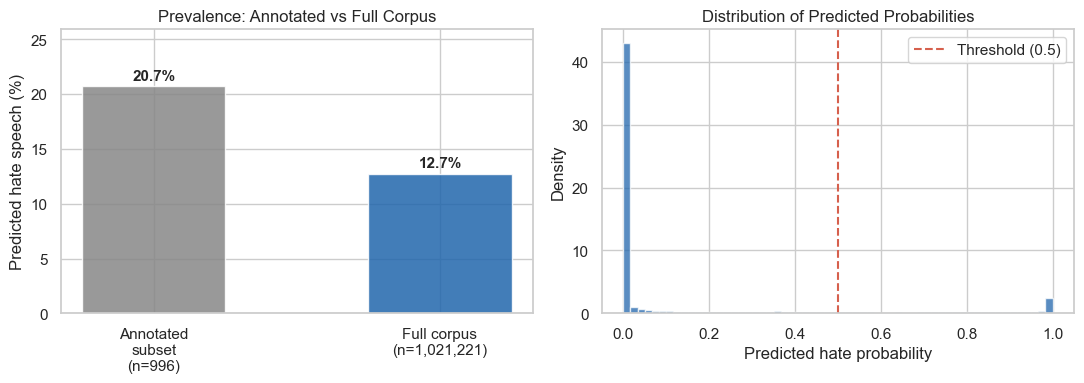

In [7]:
predicted_prev = y_pred.mean()

print('=' * 50)
print(f'  Annotated subset prevalence : {ANNOTATED_PREV*100:.1f}%  (n=996)')
print(f'  Full corpus prevalence      : {predicted_prev*100:.2f}%  (n={len(y_pred):,})')
print(f'  Ratio (full / annotated)    : {predicted_prev/ANNOTATED_PREV:.2f}x')
print('=' * 50)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: bar comparison
bars = axes[0].bar(
    ['Annotated\nsubset\n(n=996)', f'Full corpus\n(n={len(y_pred):,})'],
    [ANNOTATED_PREV * 100, predicted_prev * 100],
    color=['#878787', '#2166ac'], alpha=0.85, width=0.5,
)
for bar, val in zip(bars, [ANNOTATED_PREV * 100, predicted_prev * 100]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted hate speech (%)')
axes[0].set_title('Prevalence: Annotated vs Full Corpus')
axes[0].set_ylim(0, max(ANNOTATED_PREV, predicted_prev) * 100 * 1.25)

# Right: probability distribution
axes[1].hist(y_prob, bins=60, color='#2166ac', alpha=0.75, density=True)
axes[1].axvline(THRESHOLD, color='#d6604d', linestyle='--', linewidth=1.5, label=f'Threshold ({THRESHOLD})')
axes[1].set_xlabel('Predicted hate probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Predicted Probabilities')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'prevalence_and_distribution.png'), dpi=150)
plt.show()

## 6. Temporal Trends

Monthly predicted hate prevalence over the full collection window.
The vertical line marks the start of the Russian invasion (Feb 24, 2022).

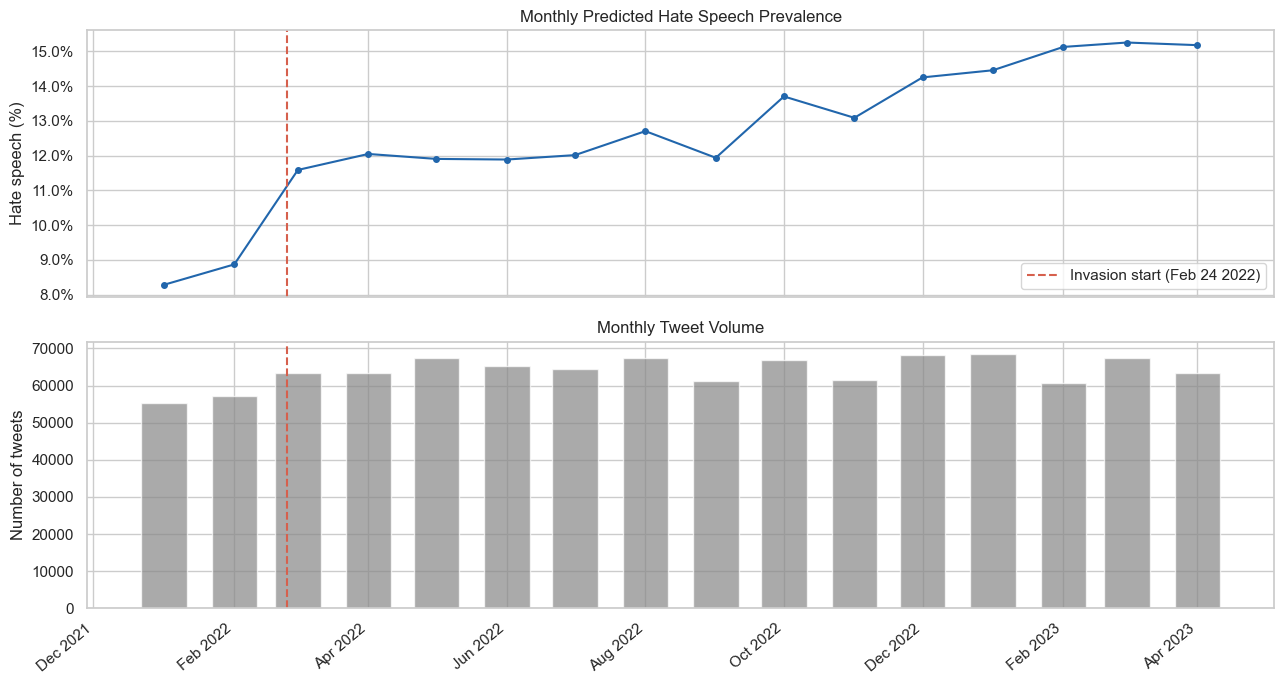

Peak hate month : March 2023  (15.3%  |  10,292 / 67,466 tweets)
Pre-invasion avg: 8.58%   Post-invasion avg: 13.22%   Delta: +4.65pp


In [8]:
if 'date_parsed' not in corpus_df.columns or corpus_df['date_parsed'].isna().all():
    print('[SKIP] No parseable date column — temporal analysis not available.')
else:
    df_time = corpus_df[['date_parsed', 'y_prob', 'y_pred']].dropna(subset=['date_parsed']).copy()
    df_time['date_parsed'] = df_time['date_parsed'].dt.tz_localize(None)  # drop tz for plotting
    df_time['month'] = df_time['date_parsed'].dt.to_period('M').dt.to_timestamp()

    monthly = (
        df_time.groupby('month')
        .agg(
            n_tweets   = ('y_pred', 'count'),
            n_hate     = ('y_pred', 'sum'),
            mean_prob  = ('y_prob', 'mean'),
        )
        .assign(hate_pct = lambda d: d['n_hate'] / d['n_tweets'] * 100)
        .reset_index()
    )

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

    # Top: hate prevalence %
    axes[0].plot(monthly['month'], monthly['hate_pct'], color='#2166ac',
                 marker='o', markersize=4, linewidth=1.5)
    axes[0].axvline(INVASION_DATE, color='#d6604d', linestyle='--',
                    linewidth=1.5, label='Invasion start (Feb 24 2022)')
    axes[0].set_ylabel('Hate speech (%)')
    axes[0].set_title('Monthly Predicted Hate Speech Prevalence')
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

    # Bottom: tweet volume
    axes[1].bar(monthly['month'], monthly['n_tweets'], width=20,
                color='#878787', alpha=0.7)
    axes[1].axvline(INVASION_DATE, color='#d6604d', linestyle='--', linewidth=1.5)
    axes[1].set_ylabel('Number of tweets')
    axes[1].set_title('Monthly Tweet Volume')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=40, ha='right')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'temporal_trends.png'), dpi=150)
    plt.show()

    # Print peak month
    peak = monthly.loc[monthly['hate_pct'].idxmax()]
    print(f'Peak hate month : {peak["month"].strftime("%B %Y")}  '
          f'({peak["hate_pct"]:.1f}%  |  {int(peak["n_hate"]):,} / {int(peak["n_tweets"]):,} tweets)')
    pre  = monthly[monthly['month'] <  INVASION_DATE]['hate_pct'].mean()
    post = monthly[monthly['month'] >= INVASION_DATE]['hate_pct'].mean()
    print(f'Pre-invasion avg: {pre:.2f}%   Post-invasion avg: {post:.2f}%   Delta: {post-pre:+.2f}pp')

## 7. High-confidence Examples

Sample tweets the model is most confident are hate speech (sanitised for display).
Useful for a qualitative sanity check that the model is finding real hate, not noise.

In [9]:
N_EXAMPLES = 10

top_hate = (
    corpus_df[corpus_df['y_pred'] == 1]
    .nlargest(N_EXAMPLES, 'y_prob')[['text', 'y_prob']]
    .reset_index(drop=True)
)

print(f'Top {N_EXAMPLES} highest-confidence hate predictions (p_hate):\n')
for i, row in top_hate.iterrows():
    # Truncate long tweets for display
    snippet = row['text'][:200] + ('...' if len(row['text']) > 200 else '')
    print(f'[{i+1}] p={row["y_prob"]:.4f}  "{snippet}"\n')

Top 10 highest-confidence hate predictions (p_hate):

[1] p=0.9997  "russia u want to threten the uk with a nuke get fucked u gang of fucking vodka drinking kid killing eats ur country aint worth shit do what u want u do it ur wiped simple ur army is dogshit putin is a..."

[2] p=0.9997  "no, ukraine kill russians soldiers, russia kill ukrainian people, women and children, bastards criminals"

[3] p=0.9997  "fuck russia dirty ratr bastards fuck putin i hope the cancer takes u slowly ur  rat twat kid killing fuck boy fight ur self u fucking pussy boy  hurry up putin and die and take ur dirty rat family wit..."

[4] p=0.9997  "fuck you russia fuck you russia fuck you russia fuck you russia fuck you russia fuck you russia fuck you russia fuck you russia fuck you russia fuck you russia fuck you russia fuck you russia fuck you..."

[5] p=0.9997  "our government needs american ppl to hate this man because he is putting all their crimes and they all are paying off zelensky with our tax dollar